In [101]:
import pandas as pd
import numpy as np

df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [102]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32581, 12)


In [103]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [104]:
print("\nData Types:")
print(df.dtypes)


Data Types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


In [105]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [106]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
165


In [107]:
print("\nTarget Distribution:")
print(df["loan_status"].value_counts())


Target Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [108]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [109]:
df.describe(include="object").T

,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [110]:
categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [111]:
print("Age statistics:")
print(df["person_age"].describe())

print("\nAges greater than 100:")
print(df[df["person_age"] > 100][["person_age", "person_income", "loan_amnt", "loan_status"]])

Age statistics:
count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

Ages greater than 100:
       person_age  person_income  loan_amnt  loan_status
81            144         250000       4800            0
183           144         200000       6000            0
575           123          80004      20400            0
747           123          78000      20000            0
32297         144        6000000       5000            0


In [112]:
print("Employment length statistics:")
print(df["person_emp_length"].describe())

print("\nEmployment length greater than 50:")
print(
    df[df["person_emp_length"] > 50]
    [["person_age", "person_emp_length", "person_income", "loan_status"]]
)

Employment length statistics:
count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

Employment length greater than 50:
     person_age  person_emp_length  person_income  loan_status
0            22              123.0          59000            1
210          21              123.0         192000            0


In [113]:
print("Income statistics:")
print(df["person_income"].describe())

print("\nTop 20 highest incomes:")
print(
    df.nlargest(20, "person_income")
    [["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_status"]]
)

Income statistics:
count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: person_income, dtype: float64

Top 20 highest incomes:
       person_age  person_income  person_emp_length  loan_amnt  loan_status
32297         144        6000000               12.0       5000            0
30049          42        2039784                0.0       8450            0
32546          60        1900000                5.0       1500            0
32497          63        1782000               13.0      12025            0
31924          44        1440000                7.0       6400            0
31922          47        1362000                9.0       6600            0
17833          32        1200000                1.0      12000            0
29119          36        1200000               16.0      10000            0
29120          40        1200000                1.0      100

In [114]:
print("Loan amount statistics:")
print(df["loan_amnt"].describe())

print("\nTop 20 loan amounts:")
print(
    df.nlargest(20, "loan_amnt")
    [["person_income", "loan_amnt", "loan_percent_income", "loan_status"]]
)

Loan amount statistics:
count    32581.000000
mean      9589.371106
std       6322.086646
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12200.000000
max      35000.000000
Name: loan_amnt, dtype: float64

Top 20 loan amounts:
     person_income  loan_amnt  loan_percent_income  loan_status
0            59000      35000                 0.59            1
3            65500      35000                 0.53            1
4            54400      35000                 0.55            1
6            77100      35000                 0.45            1
7            78956      35000                 0.44            1
8            83000      35000                 0.42            1
10           85000      35000                 0.41            1
12           95000      35000                 0.37            1
13          108160      35000                 0.32            1
14          115000      35000                 0.30            0
16          120000      35000             

In [115]:
print(df["loan_int_rate"].describe())

print("\nMissing interest rate percentage:")
print(df["loan_int_rate"].isna().mean() * 100)

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64

Missing interest rate percentage:
9.563856235229121


In [116]:
print("\nInterest rate by loan grade:")
print(
    df.groupby("loan_grade")["loan_int_rate"]
      .agg(["count", "mean", "median", "min", "max"])
)


Interest rate by loan grade:
            count       mean  median    min    max
loan_grade                                        
A            9774   7.327651   7.490   5.42   9.63
B            9395  10.995555  10.990   6.00  12.69
C            5828  13.463542  13.480   6.00  16.11
D            3314  15.361448  15.310   6.00  18.49
E             881  17.009455  16.820   6.00  20.69
F             214  18.609159  18.535  15.01  22.06
G              59  20.251525  20.160  17.34  23.22


In [117]:
print(
    "Missing employment length:",
    df["person_emp_length"].isna().sum()
)

print(
    "Missing employment length %:",
    df["person_emp_length"].isna().mean() * 100
)

Missing employment length: 895
Missing employment length %: 2.7469997851508547


In [118]:
print(
    df[df["person_emp_length"].isna()]
    [["person_age", "person_income", "loan_amnt", "loan_status"]]
    .head(10)
)

     person_age  person_income  loan_amnt  loan_status
105          22          12600       2000            1
222          24         185000      35000            0
379          24          16800       3900            1
407          25          52000      24000            1
408          22          17352       2250            0
433          22          18000       2000            0
443          21          18000       5000            1
529          24          19200       7000            1
567          21          19253       6250            1
691          24          20856      10000            0


In [119]:
duplicates = df[df.duplicated(keep=False)]

print("Total duplicate records:", len(duplicates))

duplicates.head(20)

Total duplicate records: 330


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
14,23,115000,RENT,2.0,EDUCATION,A,35000,7.90,0,0.30,N,4
238,22,183000,MORTGAGE,3.0,EDUCATION,A,1000,NaN,0,0.01,N,2
252,24,85000,RENT,5.0,MEDICAL,B,25000,10.62,0,0.29,N,4
591,26,20000,MORTGAGE,5.0,MEDICAL,A,4800,5.99,0,0.24,N,3
740,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3
817,22,22000,OWN,1.0,DEBTCONSOLIDATION,D,8500,15.05,0,0.39,N,4
920,26,50000,RENT,10.0,PERSONAL,B,18950,NaN,1,0.38,N,3
1094,22,24449,OWN,2.0,VENTURE,B,1800,11.89,0,0.07,N,4
1142,25,60000,RENT,3.0,PERSONAL,A,17000,6.91,0,0.28,N,2
1453,23,20400,RENT,2.0,MEDICAL,A,1200,7.90,0,0.06,N,2


In [120]:
print(
    "Duplicate groups:",
    df.duplicated().sum()
)

Duplicate groups: 165


In [121]:
target_distribution = df["loan_status"].value_counts()
target_percentage = df["loan_status"].value_counts(normalize=True) * 100

print("Target Count:")
print(target_distribution)

print("\nTarget Percentage:")
print(target_percentage)

Target Count:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Target Percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [122]:
print(
    pd.crosstab(
        df["loan_status"],
        columns="Count"
    )
)

col_0        Count
loan_status       
0            25473
1             7108


In [123]:
checks = {
    "Age <= 0": (df["person_age"] <= 0).sum(),
    "Income <= 0": (df["person_income"] <= 0).sum(),
    "Employment < 0": (df["person_emp_length"] < 0).sum(),
    "Loan amount <= 0": (df["loan_amnt"] <= 0).sum(),
    "Interest rate <= 0": (df["loan_int_rate"] <= 0).sum(),
    "Loan % income <= 0": (df["loan_percent_income"] <= 0).sum(),
    "Credit history <= 0": (df["cb_person_cred_hist_length"] <= 0).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

Age <= 0: 0
Income <= 0: 0
Employment < 0: 0
Loan amount <= 0: 0
Interest rate <= 0: 0
Loan % income <= 0: 9
Credit history <= 0: 0


In [124]:
print(
    df[
        df["cb_person_cred_hist_length"] > df["person_age"]
    ][
        [
            "person_age",
            "cb_person_cred_hist_length",
            "loan_status"
        ]
    ]
)

Empty DataFrame
Columns: [person_age, cb_person_cred_hist_length, loan_status]
Index: []


In [125]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print("Unique values:", df[col].nunique())

    if df[col].nunique() <= 20:
        print(df[col].unique())


Column: person_age
Unique values: 58

Column: person_income
Unique values: 4295

Column: person_home_ownership
Unique values: 4
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

Column: person_emp_length
Unique values: 36

Column: loan_intent
Unique values: 6
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

Column: loan_grade
Unique values: 7
['D' 'B' 'C' 'A' 'E' 'F' 'G']

Column: loan_amnt
Unique values: 753

Column: loan_int_rate
Unique values: 348

Column: loan_status
Unique values: 2
[1 0]

Column: loan_percent_income
Unique values: 77

Column: cb_person_default_on_file
Unique values: 2
['Y' 'N']

Column: cb_person_cred_hist_length
Unique values: 29


In [126]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working shape:", df_clean.shape)

Original shape: (32581, 12)
Working shape: (32581, 12)


In [127]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after = len(df_clean)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 32581
Rows after removing duplicates: 32416
Duplicates removed: 165


In [128]:
emp_median = df_clean["person_emp_length"].median()

print("Employment length median:", emp_median)

df_clean["person_emp_length"] = (
    df_clean["person_emp_length"]
    .fillna(emp_median)
)

print(
    "Missing employment length after filling:",
    df_clean["person_emp_length"].isna().sum()
)

Employment length median: 4.0
Missing employment length after filling: 0


In [129]:
grade_interest_median = (
    df_clean.groupby("loan_grade")["loan_int_rate"]
    .median()
)

print(grade_interest_median)

loan_grade
A     7.490
B    10.990
C    13.480
D    15.310
E    16.820
F    18.535
G    20.160
Name: loan_int_rate, dtype: float64


In [130]:
df_clean["loan_int_rate"] = (
    df_clean["loan_int_rate"]
    .fillna(
        df_clean.groupby("loan_grade")["loan_int_rate"]
        .transform("median")
    )
)

print(
    "Missing interest rates after filling:",
    df_clean["loan_int_rate"].isna().sum()
)

Missing interest rates after filling: 0


In [131]:
df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].mean()
)

,loan_int_rate
0,16.02
1,11.14
2,12.87
3,15.23
4,14.27
...,...
32411,13.16
32412,7.49
32413,10.99
32414,11.48


In [132]:
missing_summary = df_clean.isnull().sum()

print(missing_summary)

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [133]:
print(
    df_clean[df_clean["person_age"] > 100]
    [["person_age",
      "person_income",
      "loan_amnt",
      "loan_status"]]
)

       person_age  person_income  loan_amnt  loan_status
81            144         250000       4800            0
183           144         200000       6000            0
575           123          80004      20400            0
747           123          78000      20000            0
32132         144        6000000       5000            0


In [134]:
before = len(df_clean)

df_clean = df_clean[
    df_clean["person_age"] <= 100
].copy()

after = len(df_clean)

print("Age outlier records removed:", before - after)

Age outlier records removed: 5


In [135]:
print(
    df_clean[df_clean["person_emp_length"] > 50]
    [["person_age",
      "person_emp_length",
      "person_income",
      "loan_status"]]
)

     person_age  person_emp_length  person_income  loan_status
0            22              123.0          59000            1
210          21              123.0         192000            0


In [136]:
before = len(df_clean)

df_clean = df_clean[
    df_clean["person_emp_length"] <= 50
].copy()

after = len(df_clean)

print(
    "Employment length outlier records removed:",
    before - after
)

Employment length outlier records removed: 2


In [137]:
invalid_credit_history = df_clean[
    df_clean["cb_person_cred_hist_length"] >= df_clean["person_age"]
]

print(
    "Potentially suspicious credit-history records:",
    len(invalid_credit_history)
)

Potentially suspicious credit-history records: 0


In [138]:
invalid_credit_history[
    [
        "person_age",
        "cb_person_cred_hist_length",
        "loan_status"
    ]
].head(20)

,person_age,cb_person_cred_hist_length,loan_status


In [139]:
print("=" * 50)
print("FINAL CLEANING CHECK")
print("=" * 50)

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

FINAL CLEANING CHECK
Rows: 32409
Columns: 12

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Duplicate rows:
0


In [140]:
import os

os.makedirs("data/processed", exist_ok=True)

In [141]:
clean_path = "data/processed/credit_risk_clean.csv"

df_clean.to_csv(
    clean_path,
    index=False
)

print("Clean dataset saved successfully!")
print("Path:", clean_path)

Clean dataset saved successfully!
Path: data/processed/credit_risk_clean.csv


In [142]:
print("=" * 60)
print("FINAL CLEAN DATASET CHECK")
print("=" * 60)

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nTarget distribution:")
print(df_clean["loan_status"].value_counts())

print("\nTarget percentage:")
print(
    (df_clean["loan_status"].value_counts(normalize=True) * 100)
    .round(2)
)

FINAL CLEAN DATASET CHECK
Rows: 32409
Columns: 12

Duplicate rows: 0

Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Target distribution:
loan_status


In [143]:
print("=" * 60)
print("CLEAN DATASET OVERVIEW")
print("=" * 60)

print("Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nData Types:")
print(df_clean.dtypes)

print("\nStatistical Summary:")
display(df_clean.describe().T)

CLEAN DATASET OVERVIEW
Shape: (32409, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data Types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
person_age,32409.0,27.730754,6.210445,20.00,23.00,26.00,30.00,94.00
person_income,32409.0,65894.277053,52517.869973,4000.00,38500.00,55000.00,79200.00,2039784.00
person_emp_length,32409.0,4.761424,3.983757,0.00,2.00,4.00,7.00,41.00
loan_amnt,32409.0,9592.486655,6320.885127,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32409.0,11.020010,3.213459,5.42,7.88,10.99,13.48,23.22
loan_status,32409.0,0.218705,0.413374,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32409.0,0.170248,0.106785,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32409.0,5.811194,4.057899,2.00,3.00,4.00,8.00,30.00


In [144]:
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']


In [145]:
categorical_columns = df_clean.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


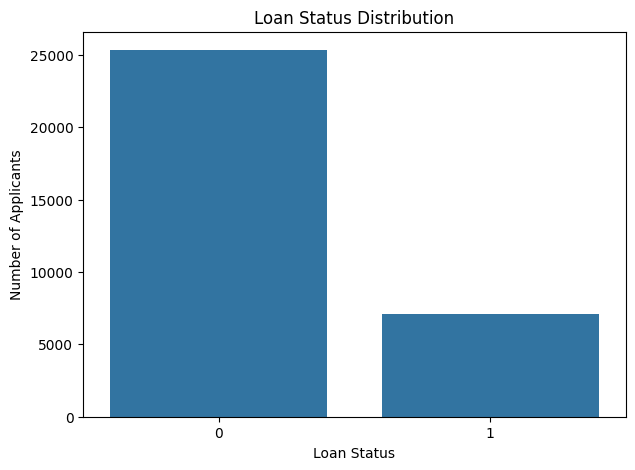

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="loan_status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

In [147]:
status_counts = df_clean["loan_status"].value_counts()

print("Loan Status Counts:")
print(status_counts)

print("\nLoan Status Percentages:")
print(
    df_clean["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Loan Status Counts:
loan_status
0    25321
1     7088
Name: count, dtype: int64

Loan Status Percentages:
loan_status
0    78.13
1    21.87
Name: proportion, dtype: float64


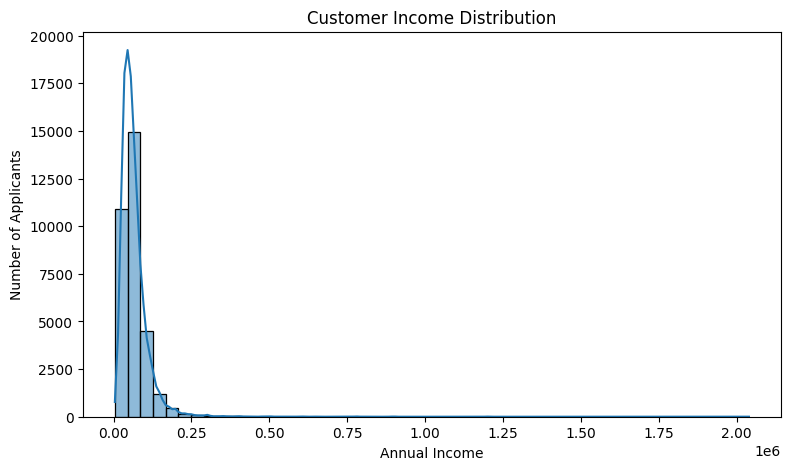

In [148]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="person_income",
    bins=50,
    kde=True
)

plt.title("Customer Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.show()

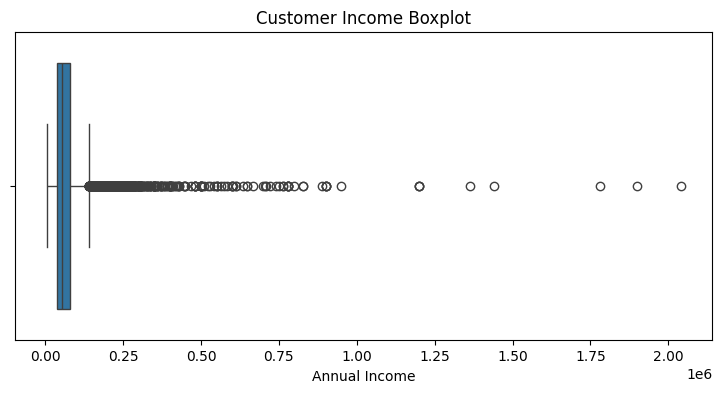

In [149]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    x=df_clean["person_income"]
)

plt.title("Customer Income Boxplot")
plt.xlabel("Annual Income")

plt.show()

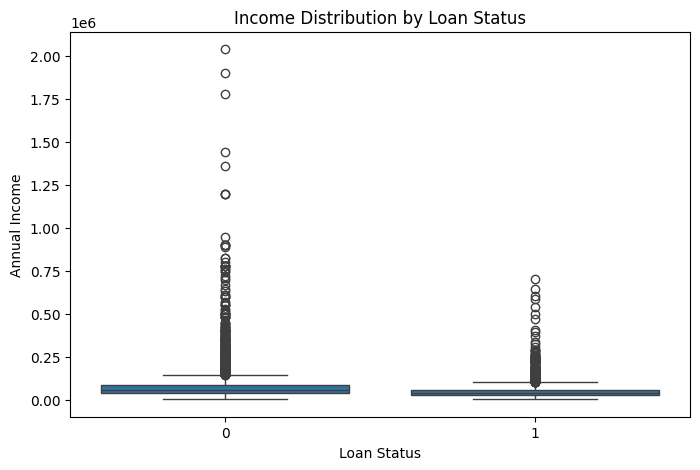

In [150]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="person_income"
)

plt.title("Income Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.show()

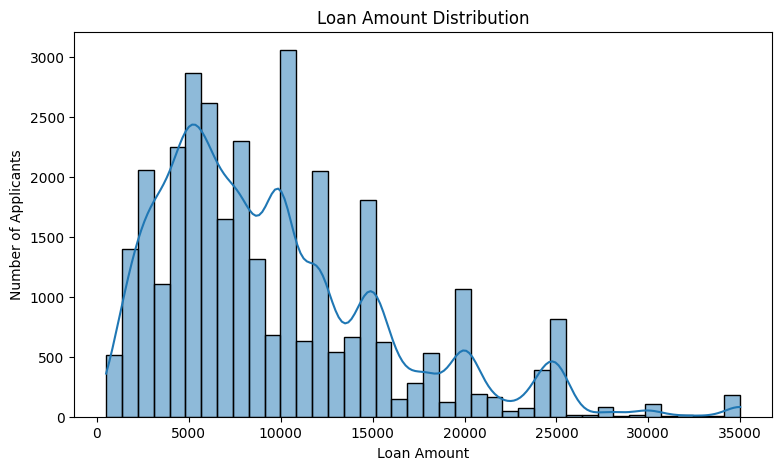

In [151]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="loan_amnt",
    bins=40,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

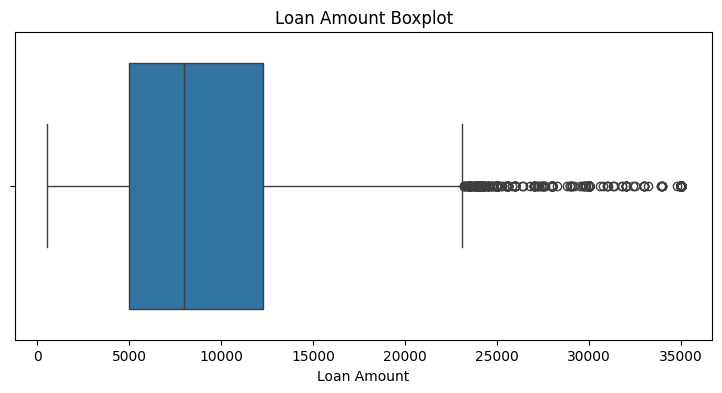

In [152]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    x=df_clean["loan_amnt"]
)

plt.title("Loan Amount Boxplot")
plt.xlabel("Loan Amount")

plt.show()

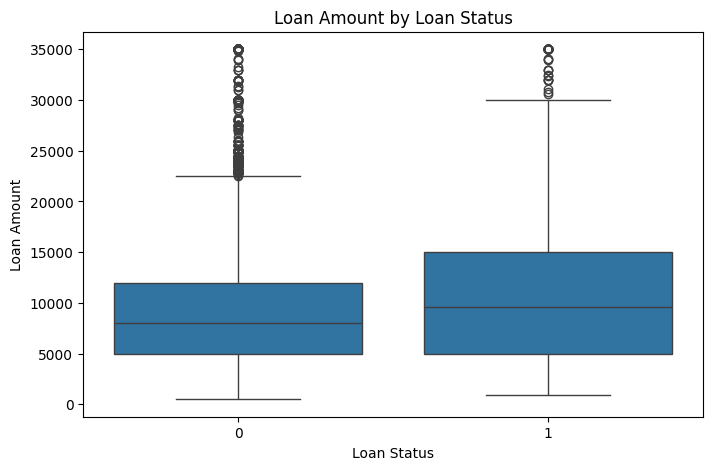

In [153]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="loan_amnt"
)

plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

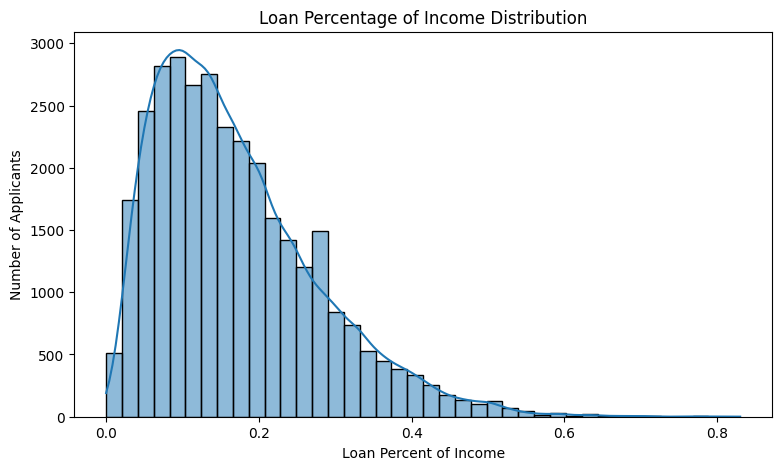

In [154]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="loan_percent_income",
    bins=40,
    kde=True
)

plt.title("Loan Percentage of Income Distribution")
plt.xlabel("Loan Percent of Income")
plt.ylabel("Number of Applicants")

plt.show()

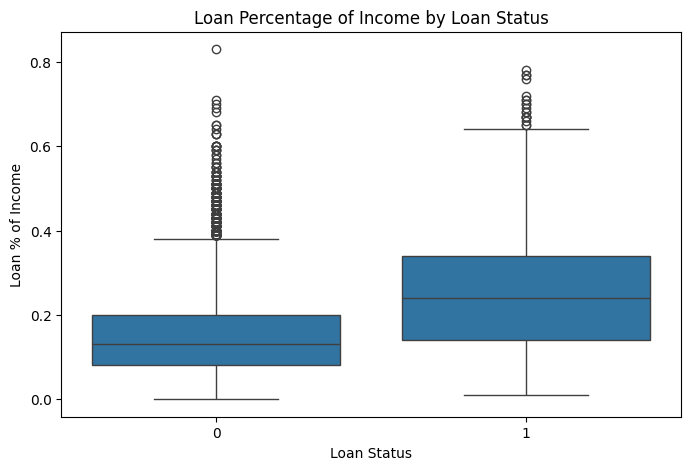

In [155]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="loan_percent_income"
)

plt.title("Loan Percentage of Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan % of Income")

plt.show()

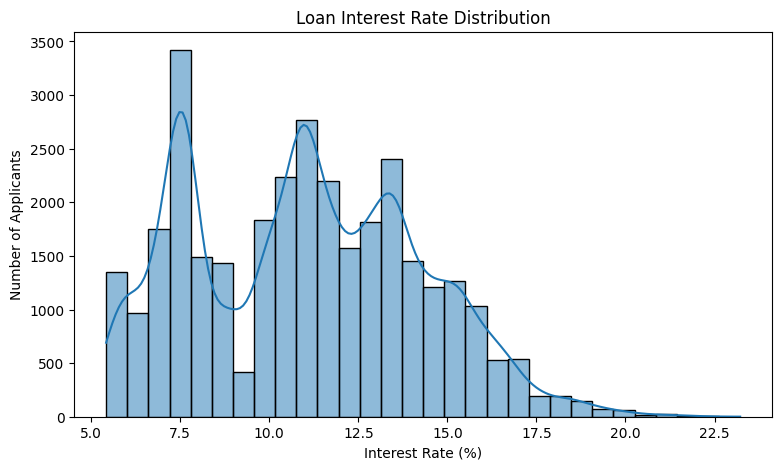

In [156]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="loan_int_rate",
    bins=30,
    kde=True
)

plt.title("Loan Interest Rate Distribution")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Applicants")

plt.show()

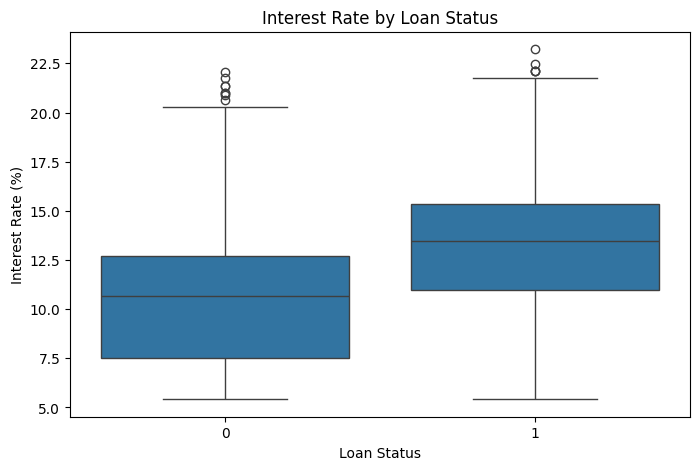

In [157]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="loan_int_rate"
)

plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")

plt.show()

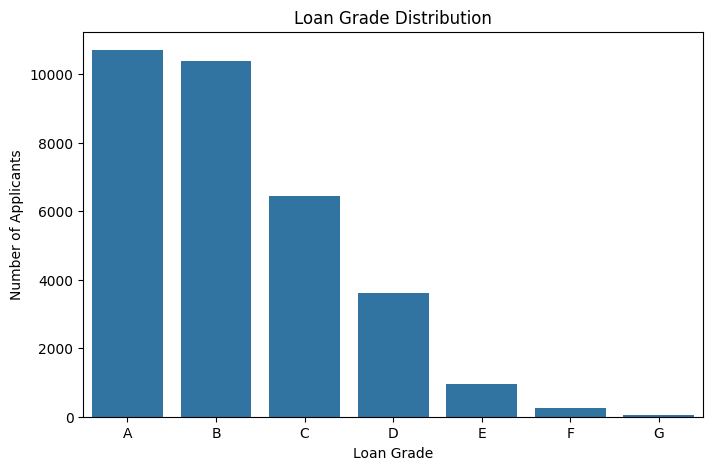

In [158]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="loan_grade",
    order=sorted(df_clean["loan_grade"].unique())
)

plt.title("Loan Grade Distribution")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Applicants")

plt.show()

In [159]:
grade_default = (
    df_clean.groupby("loan_grade")["loan_status"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default Rate by Loan Grade:")
print(grade_default)

Default Rate by Loan Grade:
loan_grade
A     9.96
B    16.32
C    20.76
D    59.05
E    64.49
F    70.54
G    98.44
Name: loan_status, dtype: float64


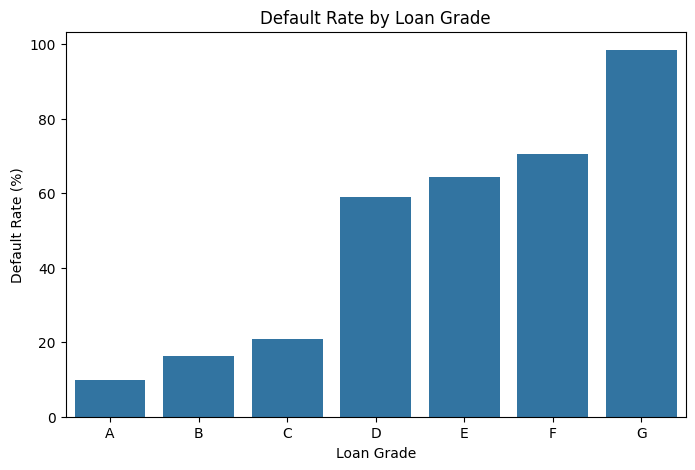

In [160]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=grade_default.index,
    y=grade_default.values
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")

plt.show()

In [161]:
intent_default = (
    df_clean.groupby("loan_intent")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Default Rate by Loan Intent:")
print(intent_default)

Default Rate by Loan Intent:
loan_intent
DEBTCONSOLIDATION    28.68
MEDICAL              26.76
HOMEIMPROVEMENT      26.15
PERSONAL             19.89
EDUCATION            17.26
VENTURE              14.86
Name: loan_status, dtype: float64


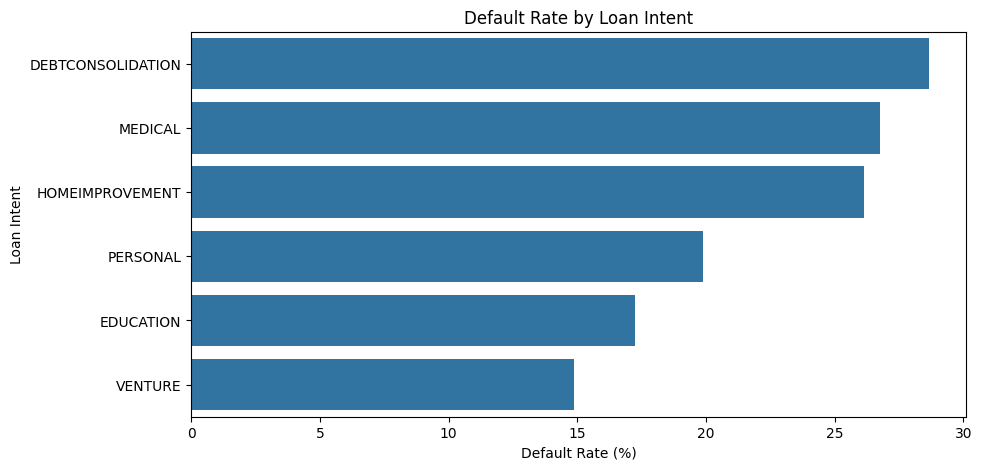

In [162]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=intent_default.values,
    y=intent_default.index
)

plt.title("Default Rate by Loan Intent")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Intent")

plt.show()

In [163]:
home_default = (
    df_clean.groupby("person_home_ownership")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Default Rate by Home Ownership:")
print(home_default)

Default Rate by Home Ownership:
person_home_ownership
RENT        31.61
OTHER       31.13
MORTGAGE    12.62
OWN          7.49
Name: loan_status, dtype: float64


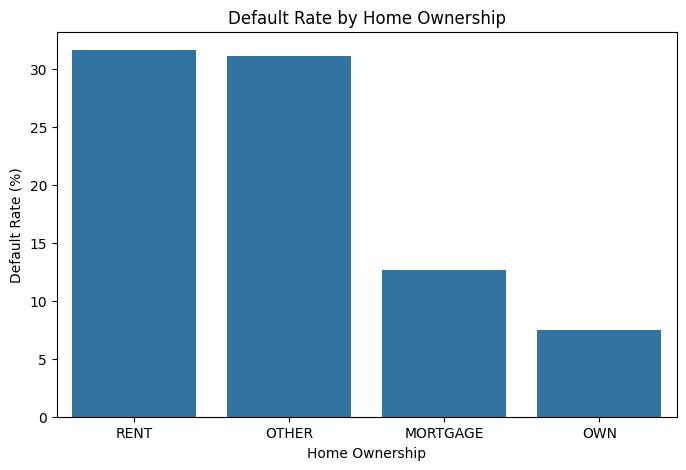

In [164]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=home_default.index,
    y=home_default.values
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")

plt.show()

In [165]:
previous_default = (
    df_clean.groupby("cb_person_default_on_file")["loan_status"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default Rate by Previous Default History:")
print(previous_default)

Default Rate by Previous Default History:
cb_person_default_on_file
N    18.44
Y    37.86
Name: loan_status, dtype: float64


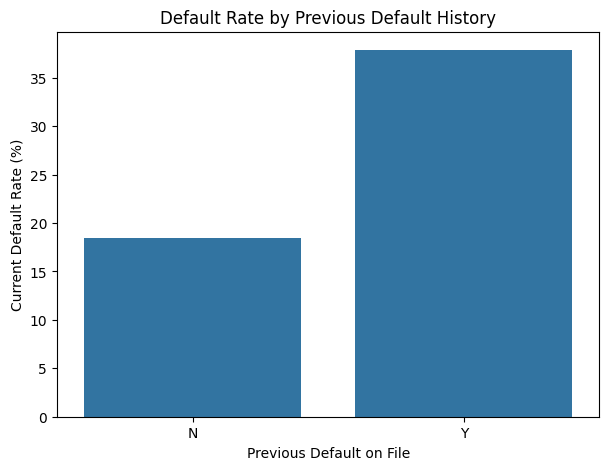

In [166]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=previous_default.index,
    y=previous_default.values
)

plt.title("Default Rate by Previous Default History")
plt.xlabel("Previous Default on File")
plt.ylabel("Current Default Rate (%)")

plt.show()

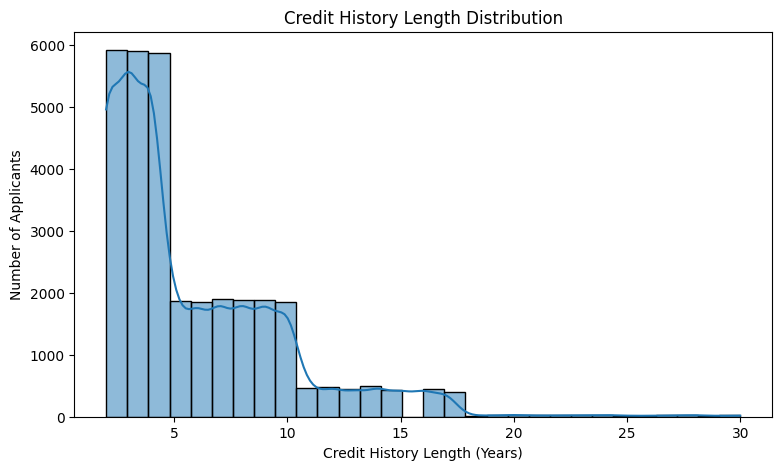

In [167]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="cb_person_cred_hist_length",
    bins=30,
    kde=True
)

plt.title("Credit History Length Distribution")
plt.xlabel("Credit History Length (Years)")
plt.ylabel("Number of Applicants")

plt.show()

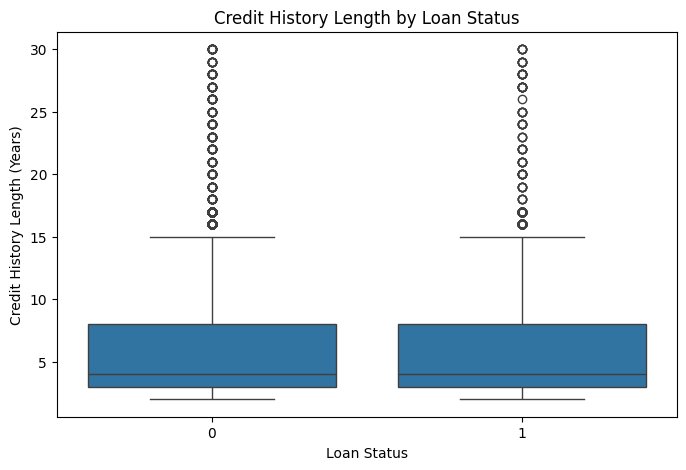

In [168]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="cb_person_cred_hist_length"
)

plt.title("Credit History Length by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit History Length (Years)")

plt.show()

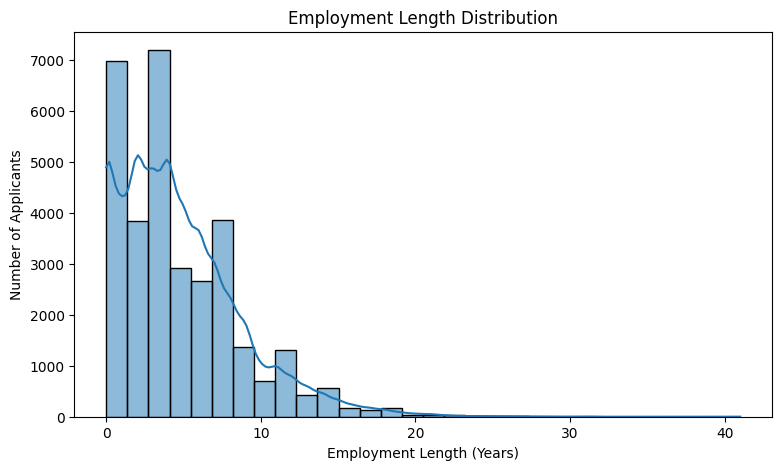

In [169]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="person_emp_length",
    bins=30,
    kde=True
)

plt.title("Employment Length Distribution")
plt.xlabel("Employment Length (Years)")
plt.ylabel("Number of Applicants")

plt.show()

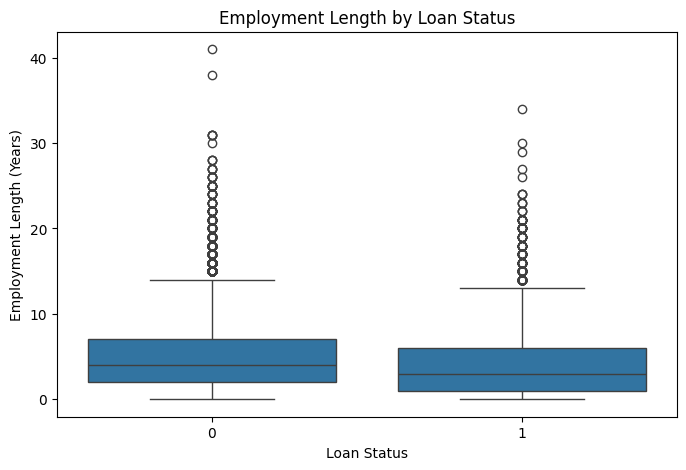

In [170]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="person_emp_length"
)

plt.title("Employment Length by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Employment Length (Years)")

plt.show()

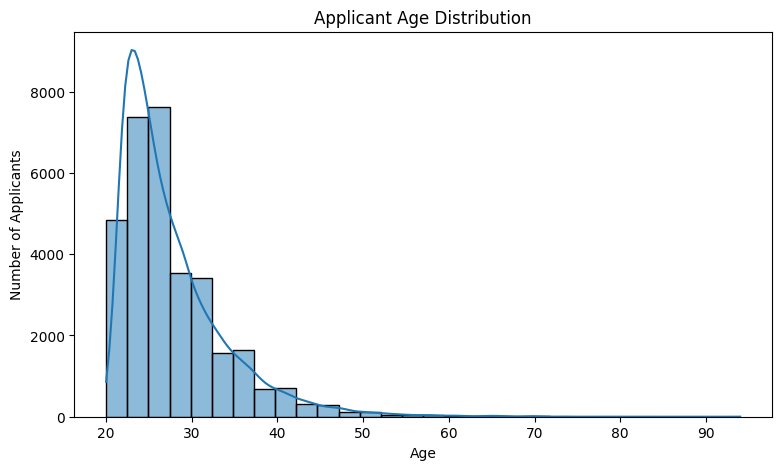

In [171]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="person_age",
    bins=30,
    kde=True
)

plt.title("Applicant Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.show()

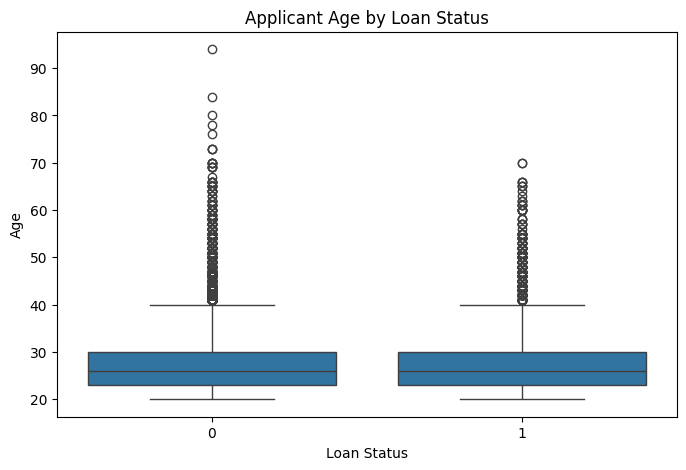

In [172]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="loan_status",
    y="person_age"
)

plt.title("Applicant Age by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Age")

plt.show()

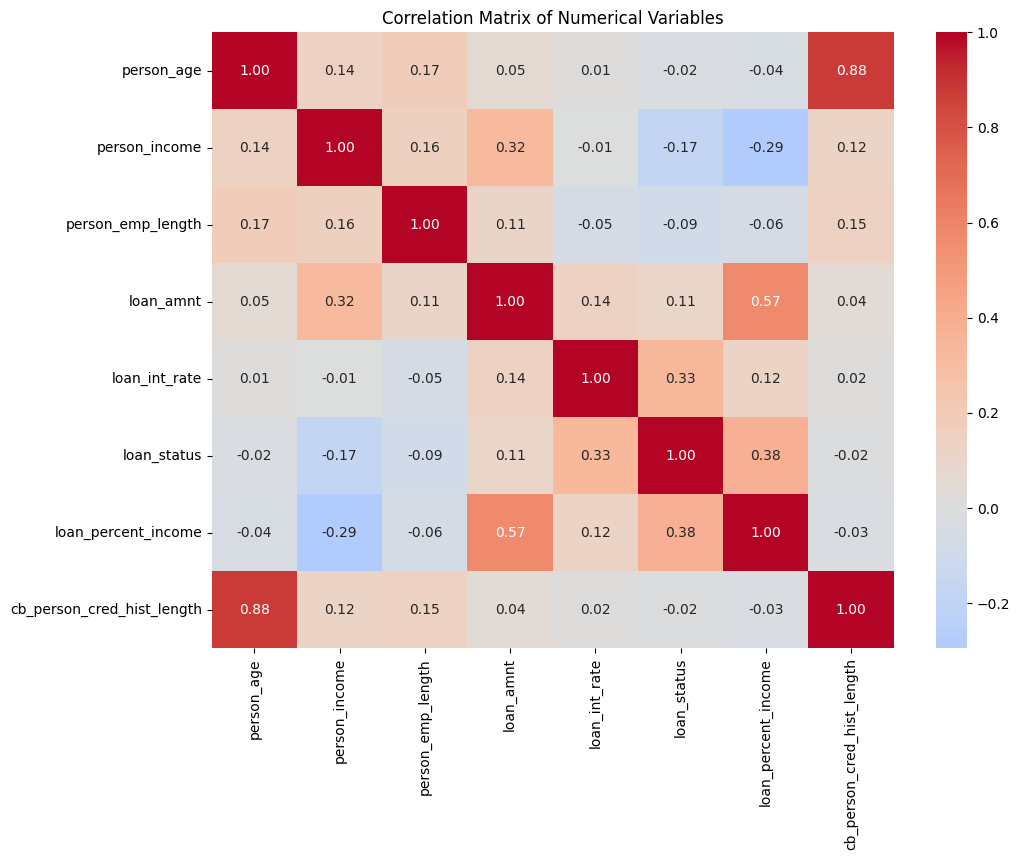

In [173]:
plt.figure(figsize=(11, 8))

correlation = df_clean.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [174]:
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (32409, 11)
Target shape: (32409,)


In [175]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (25927, 11)
Testing data: (6482, 11)

Training target distribution:
loan_status
0    0.781309
1    0.218691
Name: proportion, dtype: float64

Testing target distribution:
loan_status
0    0.78124
1    0.21876
Name: proportion, dtype: float64


In [177]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [178]:
df_clean = pd.get_dummies(df_clean)

In [179]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [180]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [181]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [182]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

In [183]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

In [184]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

In [185]:
print("Training Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


In [186]:
print("Training Decision Tree...")

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree training completed.")

Training Decision Tree...
Decision Tree training completed.


In [187]:
print("Training Random Forest...")

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [194]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_tree = decision_tree_pipeline.predict(X_test)
y_pred_forest = random_forest_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_forest = random_forest_pipeline.predict_proba(X_test)[:, 1]

def evaluate_model(model_name, y_true, y_pred, y_prob):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        y_prob_logistic
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree,
        y_prob_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_forest,
        y_prob_forest
    )
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(results_df.round(4))

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9358,0.9744,0.7257,0.8319,0.9359
1,Logistic Regression,0.8630,0.7563,0.5515,0.6378,0.8703
2,Decision Tree,0.8948,0.7473,0.7842,0.7653,0.8550


In [195]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_forest)

print("Random Forest Confusion Matrix:")
print(cm)

Random Forest Confusion Matrix:
[[5037   27]
 [ 389 1029]]


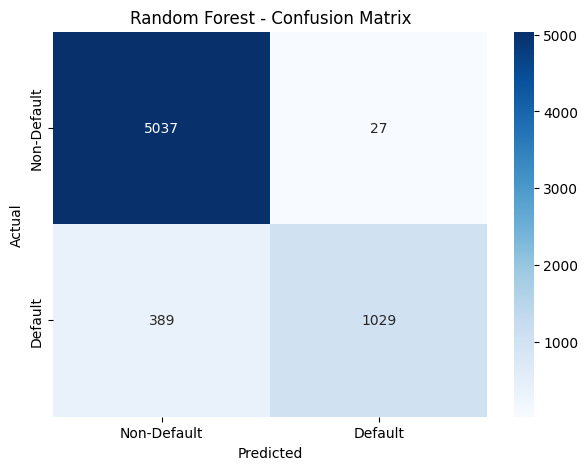

In [196]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [197]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_forest
).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 5037
False Positives: 27
False Negatives: 389
True Positives  : 1029


In [198]:
print("\nRisk Analysis:")
print("Actual Defaults:", fn + tp)
print("Correctly Identified Defaults:", tp)
print("Missed Defaults:", fn)

print(
    "Default Detection Rate:",
    round(tp / (tp + fn) * 100, 2),
    "%"
)


Risk Analysis:
Actual Defaults: 1418
Correctly Identified Defaults: 1029
Missed Defaults: 389
Default Detection Rate: 72.57 %


In [199]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

for threshold in thresholds:

    predictions = (
        y_prob_forest >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(3)
)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.845,0.781,0.812
1,0.35,0.893,0.766,0.825
2,0.40,0.930,0.750,0.831
3,0.45,0.961,0.738,0.834
4,0.50,0.974,0.726,0.832
5,0.55,0.983,0.718,0.830
6,0.60,0.986,0.713,0.828
7,0.65,0.990,0.708,0.826
8,0.70,0.992,0.700,0.821


In [200]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best threshold based on F1 Score:")
print(best_threshold_row)

Best threshold based on F1 Score:
Threshold    0.450000
Precision    0.960514
Recall       0.737659
F1 Score     0.834464
Name: 3, dtype: float64


In [201]:
best_threshold = best_threshold_row["Threshold"]

print(
    "\nSelected threshold:",
    best_threshold
)


Selected threshold: 0.45


In [202]:
rf_model = random_forest_pipeline.named_steps["model"]

feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

,Feature,Importance
5,num__loan_percent_income,0.219447
1,num__person_income,0.142792
4,num__loan_int_rate,0.114900
3,num__loan_amnt,0.074162
2,num__person_emp_length,0.060285
20,cat__loan_grade_D,0.055195
10,cat__person_home_ownership_RENT,0.053718
0,num__person_age,0.044843
6,num__cb_person_cred_hist_length,0.034614
7,cat__person_home_ownership_MORTGAGE,0.028703


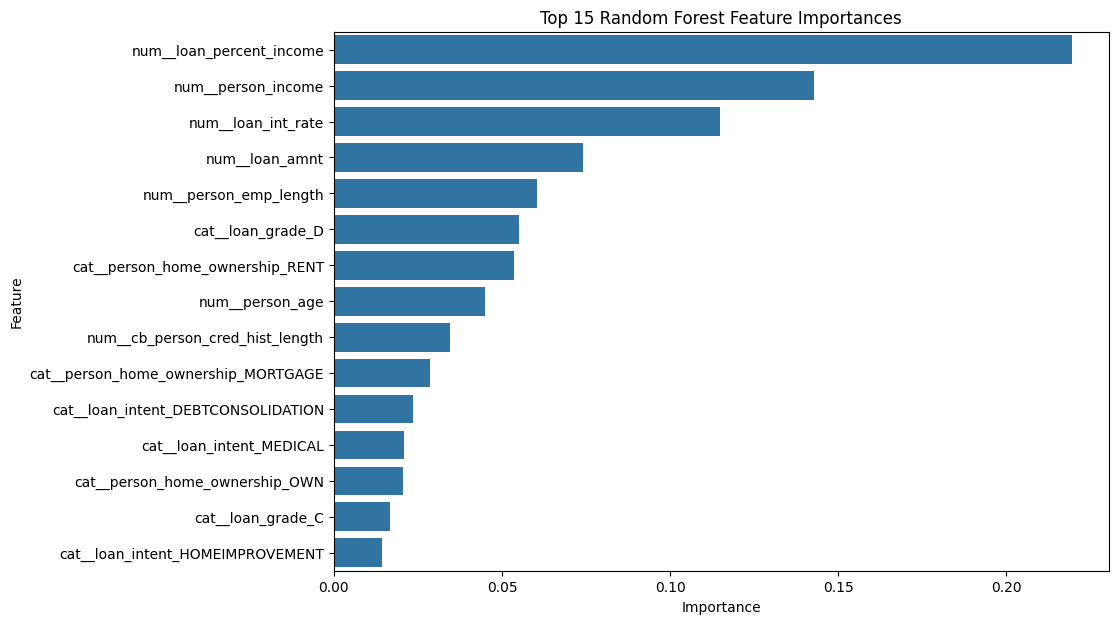

In [203]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [204]:
risk_probability = y_prob_forest

risk_score = risk_probability * 100

In [205]:
risk_preview = pd.DataFrame({
    "Actual_Status": y_test.values,
    "Default_Probability": risk_probability,
    "Risk_Score": risk_score
})

display(
    risk_preview.head(10).round(3)
)

,Actual_Status,Default_Probability,Risk_Score
0,0,0.085,8.5
1,1,0.190,19.0
2,0,0.035,3.5
3,0,0.060,6.0
4,1,0.995,99.5
5,0,0.025,2.5
6,1,0.935,93.5
7,0,0.030,3.0
8,0,0.000,0.0
9,0,0.000,0.0


In [206]:
def assign_risk_category(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [207]:
risk_preview["Risk_Category"] = (
    risk_preview["Default_Probability"]
    .apply(assign_risk_category)
)

display(risk_preview.head(10).round(3))

,Actual_Status,Default_Probability,Risk_Score,Risk_Category
0,0,0.085,8.5,Low Risk
1,1,0.190,19.0,Low Risk
2,0,0.035,3.5,Low Risk
3,0,0.060,6.0,Low Risk
4,1,0.995,99.5,High Risk
5,0,0.025,2.5,Low Risk
6,1,0.935,93.5,High Risk
7,0,0.030,3.0,Low Risk
8,0,0.000,0.0,Low Risk
9,0,0.000,0.0,Low Risk


In [208]:
risk_preview["Approval_Probability"] = (
    1 - risk_preview["Default_Probability"]
)

risk_preview["Approval_Probability"] = (
    risk_preview["Approval_Probability"] * 100
)

display(
    risk_preview.head(10).round(2)
)

,Actual_Status,Default_Probability,Risk_Score,Risk_Category,Approval_Probability
0,0,0.08,8.5,Low Risk,91.5
1,1,0.19,19.0,Low Risk,81.0
2,0,0.04,3.5,Low Risk,96.5
3,0,0.06,6.0,Low Risk,94.0
4,1,1.00,99.5,High Risk,0.5
5,0,0.02,2.5,Low Risk,97.5
6,1,0.94,93.5,High Risk,6.5
7,0,0.03,3.0,Low Risk,97.0
8,0,0.00,0.0,Low Risk,100.0
9,0,0.00,0.0,Low Risk,100.0


In [209]:
def generate_recommendation(risk_category):

    if risk_category == "Low Risk":
        return "Approve Loan"

    elif risk_category == "Medium Risk":
        return "Review Manually"

    else:
        return "Reject Application"

In [210]:
risk_preview["Recommendation"] = (
    risk_preview["Risk_Category"]
    .apply(generate_recommendation)
)

display(risk_preview.head(10).round(2))

,Actual_Status,Default_Probability,Risk_Score,Risk_Category,Approval_Probability,Recommendation
0,0,0.08,8.5,Low Risk,91.5,Approve Loan
1,1,0.19,19.0,Low Risk,81.0,Approve Loan
2,0,0.04,3.5,Low Risk,96.5,Approve Loan
3,0,0.06,6.0,Low Risk,94.0,Approve Loan
4,1,1.00,99.5,High Risk,0.5,Reject Application
5,0,0.02,2.5,Low Risk,97.5,Approve Loan
6,1,0.94,93.5,High Risk,6.5,Reject Application
7,0,0.03,3.0,Low Risk,97.0,Approve Loan
8,0,0.00,0.0,Low Risk,100.0,Approve Loan
9,0,0.00,0.0,Low Risk,100.0,Approve Loan


In [211]:
print("=" * 80)
print("CREDIT RISK PREDICTION SYSTEM")
print("=" * 80)

display(
    risk_preview.head(20).round(2)
)

CREDIT RISK PREDICTION SYSTEM


,Actual_Status,Default_Probability,Risk_Score,Risk_Category,Approval_Probability,Recommendation
0,0,0.08,8.5,Low Risk,91.5,Approve Loan
1,1,0.19,19.0,Low Risk,81.0,Approve Loan
2,0,0.04,3.5,Low Risk,96.5,Approve Loan
3,0,0.06,6.0,Low Risk,94.0,Approve Loan
4,1,1.00,99.5,High Risk,0.5,Reject Application
5,0,0.02,2.5,Low Risk,97.5,Approve Loan
6,1,0.94,93.5,High Risk,6.5,Reject Application
7,0,0.03,3.0,Low Risk,97.0,Approve Loan
8,0,0.00,0.0,Low Risk,100.0,Approve Loan
9,0,0.00,0.0,Low Risk,100.0,Approve Loan


In [212]:
risk_distribution = (
    risk_preview["Risk_Category"]
    .value_counts()
)

print("Risk Category Distribution:")
print(risk_distribution)

Risk Category Distribution:
Risk_Category
Low Risk       5171
High Risk      1025
Medium Risk     286
Name: count, dtype: int64


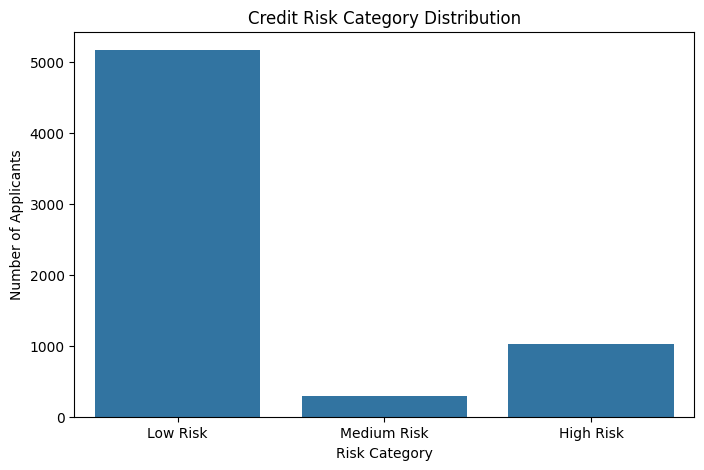

In [213]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_preview,
    x="Risk_Category",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Credit Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Applicants")

plt.show()

In [214]:
recommendation_distribution = (
    risk_preview["Recommendation"]
    .value_counts()
)

print("Recommendation Distribution:")
print(recommendation_distribution)

Recommendation Distribution:
Recommendation
Approve Loan          5171
Reject Application    1025
Review Manually        286
Name: count, dtype: int64


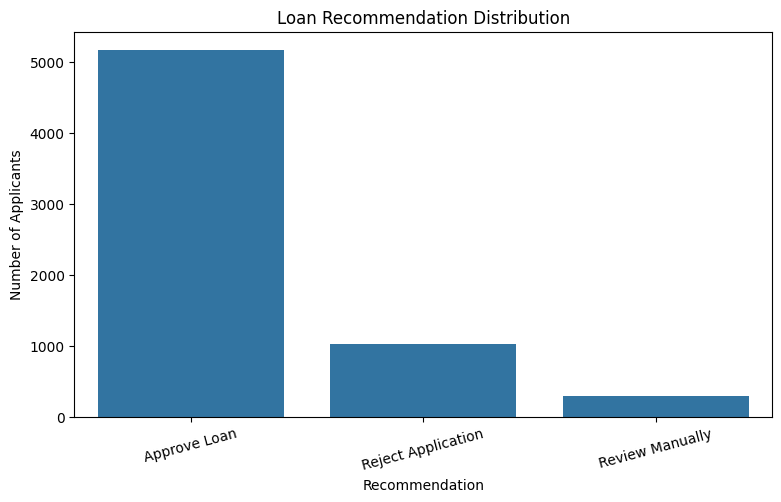

In [215]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=risk_preview,
    x="Recommendation"
)

plt.title("Loan Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=15)

plt.show()

In [216]:
risk_actual = pd.crosstab(
    risk_preview["Risk_Category"],
    risk_preview["Actual_Status"],
    normalize="index"
) * 100

risk_actual.columns = [
    "Non-Default %",
    "Default %"
]

display(
    risk_actual.round(2)
)

,Non-Default %,Default %
Risk_Category,,
High Risk,1.37,98.63
Low Risk,94.01,5.99
Medium Risk,66.08,33.92


In [217]:
os.makedirs(
    "data/predictions",
    exist_ok=True
)

prediction_path = (
    "data/predictions/credit_risk_predictions.csv"
)

risk_preview.to_csv(
    prediction_path,
    index=False
)

print("Prediction results saved to:")
print(prediction_path)

Prediction results saved to:
data/predictions/credit_risk_predictions.csv


In [218]:
def predict_credit_risk(
    age,
    income,
    home_ownership,
    employment_length,
    loan_intent,
    loan_grade,
    loan_amount,
    interest_rate,
    loan_percent_income,
    previous_default,
    credit_history_length
):

    applicant = pd.DataFrame({
        "person_age": [age],
        "person_income": [income],
        "person_home_ownership": [home_ownership],
        "person_emp_length": [employment_length],
        "loan_intent": [loan_intent],
        "loan_grade": [loan_grade],
        "loan_amnt": [loan_amount],
        "loan_int_rate": [interest_rate],
        "loan_percent_income": [loan_percent_income],
        "cb_person_default_on_file": [previous_default],
        "cb_person_cred_hist_length": [credit_history_length]
    })

    probability = (
        random_forest_pipeline
        .predict_proba(applicant)[0][1]
    )

    score = probability * 100

    category = assign_risk_category(probability)

    approval_probability = (
        1 - probability
    ) * 100

    recommendation = generate_recommendation(
        category
    )

    return {
        "Default Probability (%)": round(
            probability * 100, 2
        ),
        "Approval Probability (%)": round(
            approval_probability, 2
        ),
        "Risk Score": round(score, 2),
        "Risk Category": category,
        "Recommendation": recommendation
    }

In [219]:
sample_result = predict_credit_risk(
    age=25,
    income=500000,
    home_ownership="RENT",
    employment_length=3,
    loan_intent="EDUCATION",
    loan_grade="B",
    loan_amount=10000,
    interest_rate=11.0,
    loan_percent_income=0.20,
    previous_default="N",
    credit_history_length=4
)

print("=" * 60)
print("SAMPLE CREDIT RISK PREDICTION")
print("=" * 60)

for key, value in sample_result.items():
    print(f"{key}: {value}")

SAMPLE CREDIT RISK PREDICTION
Default Probability (%): 12.5
Approval Probability (%): 87.5
Risk Score: 12.5
Risk Category: Low Risk
Recommendation: Approve Loan
